In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime


c:\Users\DEBA\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\DEBA\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# Indice d'exposition climatique des communes
---
**Objectif**: Déterminer un indice d'exposition des communes aux risques climatique.

**Méthodologie**: 
> Calcul de l'indice d'exposition
    $$
        Exposition = note relative au nombre d’aléas climatiques × note relative à la densité de population / 10
                   = [(nombre d’aléas déclarés/nombre d’aléas possibles × 10) × (quantile de la densité de population × 10)] / 10
    $$ <br>

    $$
        NB_ALEAclim = ALEAinondation + ALEAfeu + ALEAtempête + ALEAavalanche + ALEAmvt
    $$
> Discrétisation en classes d'exposition:
     Application d'une segmentation à la Jenks avec en amont six classes spécifiées. <br>

**Données**:
>Base 1: Aléas climatiques par commune et catastrophes naturelles
>> Les aléas climatiques sont estimés à partir des communes déclarées à risques majeurs par les services de l’État dans la base de données « gestion assistée des procédures administratives relatives aux risques naturels et technologiques » gérée par les services du ministère en charge de l’Environnement (MTES/DGPR, Gaspar 
2017).
>> Pour un aléa donné, il est considéré que cet aléa est identifié sur cette commune :
>>> si la commune a été déclarée à risque pour cet aléa par les services de l’État (source : MTES, Gaspar, 2017. Traitements : SDES, 2018) ;
>>> ou si cette commune a fait l’objet d’au moins trois arrêtés de Cat-Nat pour cet aléa entre 1982 et la date considérée 
(source : MTES/DGPR, Gaspar, 2016).

>Base 2: Densité de la population par commune
>> Données issues du recensement de la population. Nous nous interesserons aux données de 2010, 2015 et 2021.
>> Pour chaque année on considérera comme densité la densité la plus récente connue.

**Pour aller plus loin**: On pourra explorer la possibilité d'inclure la fréquence des catastrophes naturelles dans le calcul de l'indice d'exposition.

## Aléas Climatiques et catastrophes climatiques au sein des communes
L'indicateur d'exposition des populations aux risques climatiques confronte l’aléa (événement naturel potentiellement dangereux, d’occurrence et d’intensité
données) et les enjeux (populations ou biens susceptibles d’être affectés par le phénomène naturel). En l’occurrence, l’indicateur, déterminé à l’échelle communale, résulte du croisement entre la densité de population et **le nombre d’aléas climatiques identifiés et déclarés par les services de l’État pour chaque commune**.

Ces aléas naturels correspondent à ceux susceptibles d’être directement ou indirectement influencés par le changement 
climatique : 

> avalanches, <br>
> Phénomène atmosphérique: <br>
>> « cyclones/ouragan (vent) » <br>
>> « tempête et grains (vent) » <br>

Si une commune est déclarée à risque majeur pour ces deux aléas, pour autant elle n’est 
identifiée à risque « phénomènes météorologiques » qu’une seule fois. 

> feux de forêt, <br>
> inondations: <br>
>> crue à débordement de cours d’eau, <br>
>> crue torrentielle ou à montée rapide de cours d’eau, <br>
>> ruissellement et coulée de boue, <br>
>> lave torrentielle (torrent et talweg), <br>
>> remontée de nappes naturelles, <br>
>> submersion marine. <br>

Dès lors qu’au moins l’un de ces types d’aléa est identifié pour une commune, celle-ci est déclarée à risque majeur 
« inondation ». Par conséquent, si une commune fait l’objet par exemple d’une déclaration à risque majeur « crue 
par débordement de cours d’eau », mais également « ruissellement et coulée de boue », pour autant elle n’est 
identifiée à risque « inondation » qu’une seule fois.

> mouvements de terrain: <br>
>> affaissement et effondrement liés aux cavités souterraines (hors mines),<br>
>> éboulement,<br>
>> chute de pierres et de blocs,<br>
>> glissement de terrain,<br>
>> avancée dunaire,<br>
>> recul du trait de côte et de falaises,<br>
>> tassement différentiel <br>

Dès lors qu’au moins l’un de ces types d’aléa est identifié dans une 
commune, celle-ci est déclarée à risque majeur « mouvement de terrain ». Si une commune est par exemple 
déclarée à risque majeur « affaissements et effondrements liés aux cavités souterraines » et « tassements 
différentiels », elle n’est identifiée à risque mouvement de terrain qu’une seule fois.


Ainsi, l’exposition des populations se révèle d’autant plus forte, que la densité de population de la commune, d’une part, 
et le nombre d’aléas climatiques identifiés et déclarés par les services de l’État d’autre part, sont élevés.

### Communes à risque et catastrophes naturelles reconnues

In [5]:
# Importation des données
# Aléa reconnus sur les communes
risque = pd.read_csv("../Data/risq_gaspar.csv", sep = ";")

# catnat reconnues
catnat = pd.read_csv("../Data/catnat_gaspar.csv", sep=";")

C:\Users\DEBA\AppData\Local\Temp\ipykernel_12908\2277590488.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  catnat = pd.read_csv("../Data/catnat_gaspar.csv", sep=";")


In [6]:
risque.head()

,cod_commune,lib_commune,lib_risque
0,01001,L'Abergement-Clémenciat,Inondation
1,01001,L'Abergement-Clémenciat,Par une crue à débordement lent de cours d'eau
2,01001,L'Abergement-Clémenciat,Séisme
3,01001,L'Abergement-Clémenciat,Transport de marchandises dangereuses
4,01002,L'Abergement-de-Varey,Mouvement de terrain


In [7]:
risque.lib_risque.unique()

array(['Inondation', "Par une crue à débordement lent de cours d'eau",
       'Séisme', 'Transport de marchandises dangereuses',
       'Mouvement de terrain', 'Glissement de terrain',
       "Par une crue torrentielle ou à montée rapide de cours d'eau",
       'Rupture de barrage',
       'Eboulement ou chutes de pierres et de blocs', 'Risque industriel',
       'Effet thermique', 'Effet toxique', 'Effet de projection',
       'Nucléaire', 'Avalanche', 'Par ruissellement et coulée de boue',
       'Effet de surpression', 'Feu de forêt', 'Affaissement minier',
       'Effondrements localisés', 'Tassements',
       'Glissements ou mouvements de pente', 'Tassements différentiels',
       'Affaissements progressifs', 'Emissions en surface de gaz de mine',
       'Radon', 'Par submersion marine',
       'Recul du trait de côte et de falaises',
       'Effondrements généralisés', 'Engins de guerre',
       "Phénomène lié à l'atmosphère", 'Neige et pluies verglaçantes',
       'Par remontées

In [8]:
# Spécification des aléas climatiques
risque.loc[risque.lib_risque.isin(['Cyclone / Ouragan (vent)',
                                   'Tempête et grains (vent)'
                                  ]), "lib_risque"] = "Phénomène atmosphérique"

risque.loc[risque.lib_risque.isin(['Inondation',
                                   "Par une crue à débordement lent de cours d'eau",
                                   "Par une crue torrentielle ou à montée rapide de cours d'eau",
                                   'Par ruissellement et coulée de boue',
                                   'Par submersion marine',
                                   'Par remontées de nappes naturelles',
                                   'Par lave torrentielle (torrent et talweg)' 
                                 ]), "lib_risque"] = "Inondation"

risque.loc[risque.lib_risque.isin(['Mouvement de terrain',
                                   'Glissement de terrain',
                                   'Eboulement ou chutes de pierres et de blocs',
                                   'Tassements différentiels',
                                   'Recul du trait de côte et de falaises',
                                   'Avancée dunaire',
                                 ]), "lib_risque"] = 'Mouvement de Terrain'

risque_climat = risque[risque.lib_risque.isin(['Avalanche',
                                         "Phénomène atmosphérique",
                                         'Feu de forêt',
                                         "Inondation",
                                         'Mouvement de Terrain' ])]

In [9]:
risque_climat.lib_risque.unique()

array(['Inondation', 'Mouvement de Terrain', 'Avalanche', 'Feu de forêt',
       'Phénomène atmosphérique'], dtype=object)

In [10]:
catnat.head()

,cod_nat_catnat,cod_commune,lib_commune,num_risque_jo,lib_risque_jo,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
0,BUDD8750027A,06120,Saint-Étienne-de-Tinée,63,Glissement de Terrain,1985-01-01 00:00:00.000,1986-12-31 00:00:00.000,1987-05-20 00:00:00.000,1987-05-24 00:00:00.000,2022-05-20 15:53:47.090
1,BUDD8750038A,2B050,Calvi,54,Inondations et/ou Coulées de Boue,1987-01-14 00:00:00.000,1987-01-15 00:00:00.000,1987-06-24 00:00:00.000,1987-07-10 00:00:00.000,2022-05-20 15:53:47.111
2,BUDD8750038A,30006,Aimargues,54,Inondations et/ou Coulées de Boue,1987-02-11 00:00:00.000,1987-02-13 00:00:00.000,1987-06-24 00:00:00.000,1987-07-10 00:00:00.000,2022-05-20 15:53:47.138
3,BUDD8750038A,30020,Aubord,54,Inondations et/ou Coulées de Boue,1987-02-11 00:00:00.000,1987-02-13 00:00:00.000,1987-06-24 00:00:00.000,1987-07-10 00:00:00.000,2022-05-20 15:53:47.138
4,BUDD8750038A,30033,Beauvoisin,54,Inondations et/ou Coulées de Boue,1987-02-11 00:00:00.000,1987-02-13 00:00:00.000,1987-06-24 00:00:00.000,1987-07-10 00:00:00.000,2022-05-20 15:53:47.138


In [11]:
catnat.dat_deb = pd.to_datetime(catnat.dat_deb)
catnat.dat_fin = pd.to_datetime(catnat.dat_fin)
catnat.dat_pub_arrete = pd.to_datetime(catnat.dat_pub_arrete)
catnat.dat_pub_jo = pd.to_datetime(catnat.dat_pub_jo)
catnat.dat_maj = pd.to_datetime(catnat.dat_maj)

In [12]:
catnat.describe()

,dat_deb,dat_fin,dat_pub_arrete,dat_pub_jo,dat_maj
count,261331,261331,261331,261331,261331
mean,1999-11-06 15:22:36.803440768,2000-01-11 13:39:34.960490752,2000-05-19 08:50:09.838097920,2000-05-28 11:44:42.391296896,2022-06-26 01:23:04.497398016
min,1982-08-15 00:00:00,1982-08-15 00:00:00,1982-09-21 00:00:00,1982-09-30 00:00:00,2022-05-20 15:22:19.014000
25%,1989-05-01 00:00:00,1990-02-16 00:00:00,1990-03-16 00:00:00,1990-03-23 00:00:00,2022-05-20 15:55:32.884000
50%,1999-12-25 00:00:00,1999-12-29 00:00:00,1999-12-29 00:00:00,1999-12-30 00:00:00,2022-05-24 11:17:06.953999872
75%,2009-01-24 00:00:00,2009-01-27 00:00:00,2009-01-28 00:00:00,2009-01-29 00:00:00,2022-05-24 11:39:20.860999936
max,2025-01-23 01:00:00,2025-02-05 01:00:00,2025-02-12 01:00:00,2025-02-18 01:00:00,2025-02-20 01:00:00


In [13]:
catnat.lib_risque_jo.unique()

array(['Glissement de Terrain', 'Inondations et/ou Coulées de Boue',
       'Mouvement de Terrain', 'Avalanche', 'Secousse Sismique',
       'Inondations Remontée Nappe',
       "Chocs Mécaniques liés à l'action des Vagues",
       'Effondrement et/ou Affaisement',
       'Eboulement et/ou Chute de Blocs', 'Sécheresse',
       'Vents Cycloniques', 'Raz de Marée', 'Lave Torrentielle',
       'Tempête', 'Poids de la Neige',
       'Glissement et Effondrement de Terrain',
       'Glissement et Eboulement Rocheux', 'Coulée de Boue', 'Divers',
       'Eruption Volcanique', 'Grêle',
       'Mouvements de terrain différentiels consécutifs à la sécheresse et à la réhydratation des sols',
       "Choc M�caniques li�s � l'action des Vagues", 'Séismes',
       'Mouvements de terrains (hors sécheresse géotechnique)',
       'Inondations par choc mécanique des vagues'], dtype=object)

In [14]:
# Spécification des aléas climatiques
catnat.loc[catnat.lib_risque_jo.isin(['Vents Cycloniques',
                                      'Tempête'
                                     ]), "lib_risque_jo"] = "Phénomène atmosphérique"

catnat.loc[catnat.lib_risque_jo.isin(['Inondations et/ou Coulées de Boue',
                                      'Inondations Remontée Nappe',
                                      'Lave Torrentielle', 'Coulée de Boue'
                                 ]), "lib_risque_jo"] = "Inondation"

catnat.loc[catnat.lib_risque_jo.isin(['Glissement de Terrain',
                                      'Mouvement de Terrain','Effondrement et/ou Affaisement',
                                      'Eboulement et/ou Chute de Blocs',
                                      'Glissement et Effondrement de Terrain', 
                                      'Mouvements de terrain différentiels consécutifs à la sécheresse et à la réhydratation des sols',
                                      'Glissement et Eboulement Rocheux', 
                                      'Mouvements de terrains (hors sécheresse géotechnique)'
                                 ]), "lib_risque_jo"] = 'Mouvement de Terrain'


In [15]:
catnat.lib_risque_jo.unique()

array(['Mouvement de Terrain', 'Inondation', 'Avalanche',
       'Secousse Sismique', "Chocs Mécaniques liés à l'action des Vagues",
       'Sécheresse', 'Phénomène atmosphérique', 'Raz de Marée',
       'Poids de la Neige', 'Divers', 'Eruption Volcanique', 'Grêle',
       "Choc M�caniques li�s � l'action des Vagues", 'Séismes',
       'Inondations par choc mécanique des vagues'], dtype=object)

In [16]:
# Restriction des catnat au périmètres des aléas climatiques
catnat_climat = catnat[catnat.lib_risque_jo.isin(['Mouvement de Terrain', 'Inondation', 'Avalanche', 'Phénomène atmosphérique'])]
catnat_climat.rename(columns = {'lib_risque_jo': 'lib_risque'}, inplace=True)

def alea_commune(catnat_climat, risque_climat, date_fin):
    # catnat_reconnue depuis 1982 jusqu'à date_fin
    data = catnat_climat[catnat_climat.dat_fin.dt.year <= date_fin]
    data = data.groupby(['cod_commune','lib_commune','lib_risque']).agg(nb_arret = ('lib_risque','count')).reset_index()
    data = data[data.nb_arret>=3]
    
    # Consolidation de la base des risque par commune
    data_alea_climat = pd.concat([risque_climat[['cod_commune','lib_commune','lib_risque']],
                               data[data.nb_arret>=3][['cod_commune','lib_commune','lib_risque']]]) # On complete la liste des communes et risques
    data_alea_climat.drop_duplicates(inplace = True)

    # Passage de chaque type de risque en clonne
    data_alea_climat = pd.get_dummies(data_alea_climat, columns = ['lib_risque'])
    data_alea_climat.rename(columns = {'lib_risque_Avalanche': 'Avalanche',
                                  'lib_risque_Inondation': 'Inondation',
                                  'lib_risque_Mouvement de Terrain': 'Mouvement de Terrain',
                                  'lib_risque_Phénomène atmosphérique': 'Phénomène atmosphérique',
                                  'lib_risque_Feu de forêt': 'Feu de forêt'},
                      inplace = True)
    data_alea_climat = data_alea_climat.groupby(['cod_commune', 'lib_commune']).agg('sum').reset_index()
    
    # Nb alea
    data_alea_climat["nb_alea"] = data_alea_climat['Avalanche'] + data_alea_climat['Inondation'] +\
                                    data_alea_climat['Mouvement de Terrain'] + data_alea_climat['Phénomène atmosphérique'] +\
                                        data_alea_climat['Feu de forêt']
    # Note relative à l'aléa climatique
    data_alea_climat["note_alea"] = data_alea_climat["nb_alea"]*10 / 5  # 5 représente le nombre total d'aléa possibles

    return data_alea_climat

C:\Users\DEBA\AppData\Local\Temp\ipykernel_12908\2131813539.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  catnat_climat.rename(columns = {'lib_risque_jo': 'lib_risque'}, inplace=True)


In [17]:
# Nombre d'arrêtés catnat depuis 1982 jusqu'en 2021
data_alea_climat_2021 = alea_commune(catnat_climat, risque_climat, date_fin = 2021)
data_alea_climat_2021.head()


,cod_commune,lib_commune,Avalanche,Feu de forêt,Inondation,Mouvement de Terrain,Phénomène atmosphérique,nb_alea,note_alea
0,01001,L'Abergement-Clémenciat,0,0,1,0,0,1,2.0
1,01002,L'Abergement-de-Varey,0,0,0,1,0,1,2.0
2,01004,Ambérieu-en-Bugey,0,0,1,1,0,2,4.0
3,01007,Ambronay,0,0,1,0,0,1,2.0
4,01009,Andert-et-Condon,0,0,1,0,0,1,2.0


### Quelques observations sur les aleas climatiques dans les communes

In [18]:
# Communes sur lesquelles le risque n'est pas déclaré mais dont l'état de catnat a été arrêté au moins trois fois pour ce risque
exception = catnat_climat.loc[~catnat_climat.cod_commune.isin(risque_climat.cod_commune.unique())]

In [19]:
risque.loc[risque.cod_commune.isin(exception.cod_commune.unique())].lib_risque.unique()

array(['Séisme', 'Transport de marchandises dangereuses',
       'Rupture de barrage', 'Nucléaire', 'Affaissement minier',
       'Effondrements localisés', 'Tassements',
       'Glissements ou mouvements de pente', 'Affaissements progressifs',
       'Emissions en surface de gaz de mine', 'Risque industriel',
       'Effet toxique', 'Radon', "Phénomène lié à l'atmosphère",
       'Neige et pluies verglaçantes', 'Effet thermique', 'Autre risque',
       'Effet de surpression', 'Effondrements généralisés',
       'Effet de projection', 'Engins de guerre', 'Grêle'], dtype=object)

In [20]:
catnat.loc[catnat.cod_commune.isin(exception.cod_commune.unique())].lib_risque_jo.unique()

array(['Inondation', 'Mouvement de Terrain',
       "Chocs Mécaniques liés à l'action des Vagues", 'Sécheresse',
       'Secousse Sismique', 'Poids de la Neige',
       'Phénomène atmosphérique', 'Grêle', 'Séismes'], dtype=object)

## Densité de la population au sein des communes

In [21]:
# Importer les données de densité de population
densite_pop = pd.read_excel('../Data/insee_rp_hist_1968.xlsx', skiprows=3)
densite_pop.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Densité de population
0,codgeo,libgeo,an,dens_pop
1,01001,L'Abergement-Clémenciat,1968,21.82
2,01001,L'Abergement-Clémenciat,1975,23.14
3,01001,L'Abergement-Clémenciat,1982,30
4,01001,L'Abergement-Clémenciat,1990,36.42


In [22]:
# Formatage de la table des densités
densite_pop.columns = densite_pop.loc[0]
densite_pop = densite_pop[1:]
densite_pop.rename(columns = {'codgeo': 'cod_commune', 'libgeo': 'lib_commune'}, inplace=True)

densite_pop.an = densite_pop.an.astype('int')
densite_pop.dens_pop = densite_pop.dens_pop.astype('float')

densite_pop.head()

,cod_commune,lib_commune,an,dens_pop
1,01001,L'Abergement-Clémenciat,1968,21.82
2,01001,L'Abergement-Clémenciat,1975,23.14
3,01001,L'Abergement-Clémenciat,1982,30.00
4,01001,L'Abergement-Clémenciat,1990,36.42
5,01001,L'Abergement-Clémenciat,1999,45.79


In [23]:
def density_commune(densite_pop, date):
    """date: est l'année de recensement considérée [2010, 2015, 2021]"""
    data_dens_pop = densite_pop[densite_pop.an == date]

    # Topper les communes sans densité renseignée
    data_dens_pop['top_dens_nan'] = 0
    data_dens_pop.loc[data_dens_pop.dens_pop.isna(), 'top_dens_nan'] = 1
    
    # Note relative à la densité de la population
    data_dens_pop.loc[data_dens_pop.top_dens_nan == 0, 'q_dens'] = data_dens_pop.loc[data_dens_pop.top_dens_nan == 0,'dens_pop']\
                                                                                .rank(method='min', pct=True) # Quantile de densité de population
    data_dens_pop['note_dens'] = data_dens_pop['q_dens']*10
    return data_dens_pop


In [24]:
data_dens_pop_2021 = density_commune(densite_pop, date =2021)
data_dens_pop_2021.head()

C:\Users\DEBA\AppData\Local\Temp\ipykernel_12908\1042087.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_dens_pop['top_dens_nan'] = 0
C:\Users\DEBA\AppData\Local\Temp\ipykernel_12908\1042087.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_dens_pop.loc[data_dens_pop.top_dens_nan == 0, 'q_dens'] = data_dens_pop.loc[data_dens_pop.top_dens_nan == 0,'dens_pop']\
C:\Users\DEBA\AppData\Local\Temp\ipykernel_12908\1042087.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a s

,cod_commune,lib_commune,an,dens_pop,top_dens_nan,q_dens,note_dens
8,01001,L'Abergement-Clémenciat,2021,52.33,0,0.581236,5.812355
16,01002,L'Abergement-de-Varey,2021,29.02,0,0.392617,3.926168
24,01004,Ambérieu-en-Bugey,2021,603.82,0,0.956926,9.569264
32,01005,Ambérieux-en-Dombes,2021,119.31,0,0.792279,7.922788
40,01006,Ambléon,2021,19.15,0,0.262480,2.624796


### Quelques observations sur les densités de population

Certaines commune ont été intégrées dans d'autres et d'autres ont été créées.

In [25]:
# Communes non identifiées dans la base des densité de population
data_alea_climat_2021[~data_alea_climat_2021.cod_commune.isin(densite_pop.cod_commune.unique())]

# Topper ces communes

,cod_commune,lib_commune,Avalanche,Feu de forêt,Inondation,Mouvement de Terrain,Phénomène atmosphérique,nb_alea,note_alea
28,01039,Béon,0,0,1,1,0,2,4.0
316,02077,Berzy-le-Sec,0,0,1,0,0,1,2.0
2003,08294,La Moncelle,0,0,1,1,0,2,4.0
2376,09255,Saint-Amans,0,0,0,1,0,1,2.0
4473,16140,Fontclaireau,0,0,1,0,0,1,2.0
4625,16355,Saint-Sulpice-de-Cognac,0,0,1,0,0,1,2.0
5272,18131,Lugny-Bourbonnais,0,0,0,1,0,1,2.0
6538,24089,Cazoulès,0,1,1,1,0,3,6.0
6729,24314,Orliaguet,0,1,1,1,0,3,6.0
7039,25134,Châtillon-sur-Lison,0,0,1,0,0,1,2.0


## Synthèse de l'indicateur d'exposition au risque climatique 

In [26]:
def indice_expo_climat(data_alea_climat, data_dens_pop):
    # Completer les commune de data_climat sans alea
    temp = data_dens_pop[~data_dens_pop.cod_commune.isin(data_alea_climat.cod_commune.unique())]
    data_climat = pd.concat([data_alea_climat, temp[['cod_commune', 'lib_commune']]])
    data_climat.fillna(0, inplace=True)

    # Commune ayant non présentes dans les density_pop
    temp2 = data_alea_climat[~data_alea_climat.cod_commune.isin(data_dens_pop.cod_commune.unique())]
    data_climat['top_commune_chg'] = 0
    data_climat.loc[data_climat.cod_commune.isin(temp2.cod_commune.unique()), 'top_commune_chg'] = 1
    
    data_final = data_climat.merge(data_dens_pop[['cod_commune', 'dens_pop', 'top_dens_nan','q_dens', 'note_dens']],
                         on = 'cod_commune',
                         how = 'left')
    # Calcul de l'exposition
    data_final["note_expo"] = data_final['note_alea'] * data_final['note_dens'] / 10

    return data_final

In [27]:
exposition_2021 = indice_expo_climat(data_alea_climat_2021, data_dens_pop_2021)

In [28]:
exposition_2021.head()

,cod_commune,lib_commune,Avalanche,Feu de forêt,Inondation,Mouvement de Terrain,Phénomène atmosphérique,nb_alea,note_alea,top_commune_chg,dens_pop,top_dens_nan,q_dens,note_dens,note_expo
0,01001,L'Abergement-Clémenciat,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0,52.33,0.0,0.581236,5.812355,1.162471
1,01002,L'Abergement-de-Varey,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0,29.02,0.0,0.392617,3.926168,0.785234
2,01004,Ambérieu-en-Bugey,0.0,0.0,1.0,1.0,0.0,2.0,4.0,0,603.82,0.0,0.956926,9.569264,3.827706
3,01007,Ambronay,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0,84.57,0.0,0.715554,7.155540,1.431108
4,01009,Andert-et-Condon,0.0,0.0,1.0,0.0,0.0,1.0,2.0,0,46.67,0.0,0.544062,5.440616,1.088123


OptionError: "No such keys(s): 'mode.use_inf_as_null'"

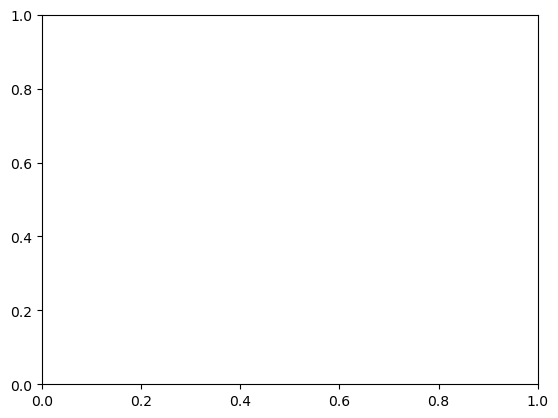

In [29]:
sns.histplot(exposition_2021[['note_expo']], kde = True)

In [ ]:
exposition_2021.isna().sum()

cod_commune                 0
lib_commune                 0
Avalanche                   0
Feu de forêt                0
Inondation                  0
Mouvement de Terrain        0
Phénomène atmosphérique     0
nb_alea                     0
note_alea                   0
top_commune_chg             0
dens_pop                   52
top_dens_nan               34
q_dens                     52
note_dens                  52
note_expo                  52
dtype: int64

In [ ]:
pip install jenkspy

     -------------------------------------- 224.7/224.7 kB 4.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [34]:
# Segmentation à la Jenks
import jenkspy

# Nombre de segment: 6
seuils = jenkspy.jenks_breaks(exposition_2021[~exposition_2021.note_expo.isna()].note_expo, n_classes = 6)

In [35]:
seuils

[0.0,
 0.5566915828965834,
 1.3429561531632157,
 2.258842397685941,
 3.29237907036687,
 4.641292207234299,
 7.964028983016869]

In [36]:
# Segmentation à la Jenks
labels = ["Aucun risque climatique déclaré", 
         "Très faible",
         "Faible",
         "Moyen",
         "Fort",
         "Très fort"]
# Ajouter une colonne de classe au DataFrame
exposition_2021['indice_expo'] = pd.cut(exposition_2021['note_expo'], bins=seuils, labels=labels, include_lowest=True)

In [37]:
# Nombre de segment: 6
seuils = [0,1,2,3,4,5,6]
labels = ["Aucun aléa climatique", 
         "1 aléa climatique",
         "2 aléas climatiques",
         "3 aléas climatiques",
         "4 aléas climatiques",
         "5 aléas climatiques"]
# Ajouter une colonne de classe au DataFrame
exposition_2021['nb_alea'] = pd.cut(exposition_2021['nb_alea'], bins=seuils, labels=labels, include_lowest=True)

In [ ]:
exposition_2021.nb_alea.unique()

['Aucun aléa climatique', '1 aléa climatique', '2 aléas climatiques', '3 aléas climatiques', '4 aléas climatiques']
Categories (6, object): ['Aucun aléa climatique' < '1 aléa climatique' < '2 aléas climatiques' < '3 aléas climatiques' < '4 aléas climatiques' < '5 aléas climatiques']

# Cartographie des niveau d'exposition

In [ ]:
pip install geopandas


     -------------------------------------- 323.6/323.6 kB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 6.1/6.1 MB 6.6 MB/s eta 0:00:00
     ---------------------------------------- 1.4/1.4 MB 5.7 MB/s eta 0:00:00
     ---------------------------------------- 16.2/16.2 MB 7.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [38]:
import geopandas as gpd
#import folium

In [39]:
# Carte des communes de france
carte_france = gpd.read_file('../Carte France/communes-20220101.shp')
carte_france.rename(columns = {'insee': 'cod_commune', 'nom': 'lib_commune'}, inplace=True)


<AxesSubplot:>

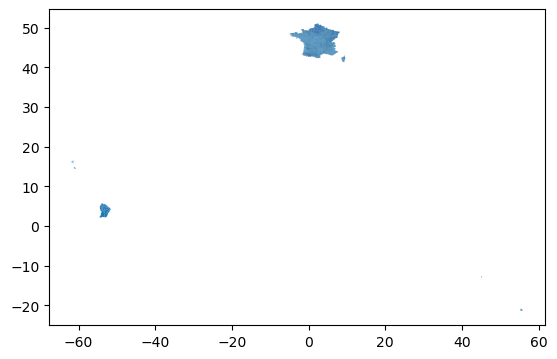

In [ ]:
carte_france.plot()

In [40]:

# Ajout correspondance commune-département
com_dep_cor = pd.read_excel('../Data/table-appartenance-geo-communes-2025.xlsx', sheet_name='COM', skiprows=5)
com_dep_cor.rename(columns = {'CODGEO':'cod_commune', 'DEP':'cod_dep'}, inplace=True)

carte_france = carte_france.merge(com_dep_cor[['cod_commune', 'cod_dep']], on = 'cod_commune', how = 'left')

In [41]:
carte_france[carte_france.cod_dep.isna()]

,cod_commune,lib_commune,wikipedia,surf_ha,geometry,cod_dep
1015,26371,Véronne,fr:Véronne,2168.0,"POLYGON ((5.17059 44.72378, 5.17095 44.72457, ...",NaN
2231,42252,Saint-Laurent-Rochefort,fr:Saint-Laurent-Rochefort,1574.0,"POLYGON ((3.87956 45.76996, 3.87962 45.77015, ...",NaN
2234,42072,La Côte-en-Couzan,fr:La Côte-en-Couzan,909.0,"POLYGON ((3.79791 45.74904, 3.79815 45.74977, ...",NaN
2408,59070,Bermeries,fr:Bermeries,529.0,"POLYGON ((3.72493 50.29002, 3.72711 50.29107, ...",NaN
2548,42109,L'Hôpital-sous-Rochefort,fr:L'Hôpital-sous-Rochefort,114.0,"POLYGON ((3.92732 45.77658, 3.9274 45.77654, 3...",NaN
...,...,...,...,...,...,...
34212,16355,Saint-Sulpice-de-Cognac,fr:Saint-Sulpice-de-Cognac,2373.0,"POLYGON ((-0.46314 45.75191, -0.46299 45.75206...",NaN
34696,35112,Fleurigné,fr:Fleurigné,1812.0,"POLYGON ((-1.14877 48.36651, -1.14873 48.36673...",NaN
34747,22309,Saint-Launeuc,fr:Saint-Launeuc,1159.0,"POLYGON ((-2.40457 48.23438, -2.40024 48.23418...",NaN
34783,22043,Coëtlogon,fr:Coëtlogon,1669.0,"POLYGON ((-2.57538 48.15147, -2.57519 48.15149...",NaN


In [42]:
# Ajout des données sur les aléas climatiques (2021)
carte_france = carte_france[['cod_commune', 'cod_dep', 'geometry']].merge(exposition_2021, on=['cod_commune'], how = 'left')

In [43]:
dom_tom_com = ['971', '972', '973', '974', '976', # DOM
       '975', '977', '978', '986', '987', '988', '984', '989'] # TOM/ COM 

hexagone = carte_france[~carte_france.cod_dep.isin(dom_tom_com)]
guadeloupe = carte_france[carte_france.cod_dep == '971']
martinique = carte_france[carte_france.cod_dep == '972']
guyane = carte_france[carte_france.cod_dep == '973']
reunion = carte_france[carte_france.cod_dep == '974']
mayotte = carte_france[carte_france.cod_dep == '976']

In [44]:
# Affichage de la carte pour différentes target (elément représenté)
def plot_climat_risque(data, target, titles):    
    data[0].plot(column=data[0][target], label = 'Hexagone', cmap = 'OrRd', legend = True, figsize=(15, 10))
    
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 10))
    j = 0   
    for carte, label in zip(data[1:], titles[1:]):
        carte.plot(column=carte[target], label = label, cmap = 'OrRd', ax=axes[j])
        j += 1
    
    plt.tight_layout()
    plt.show()


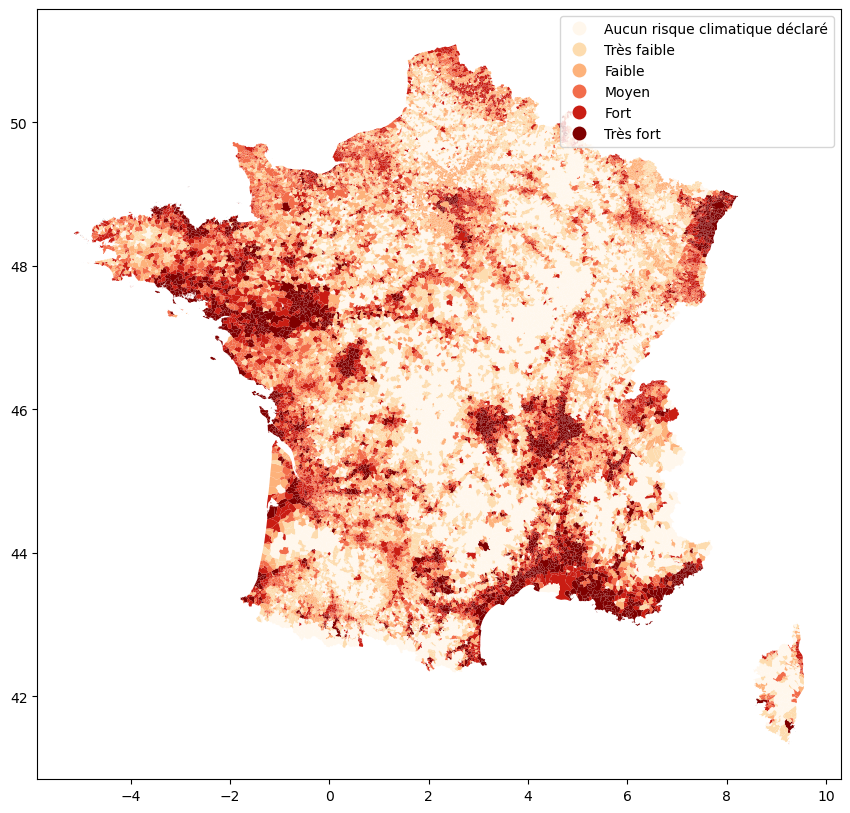

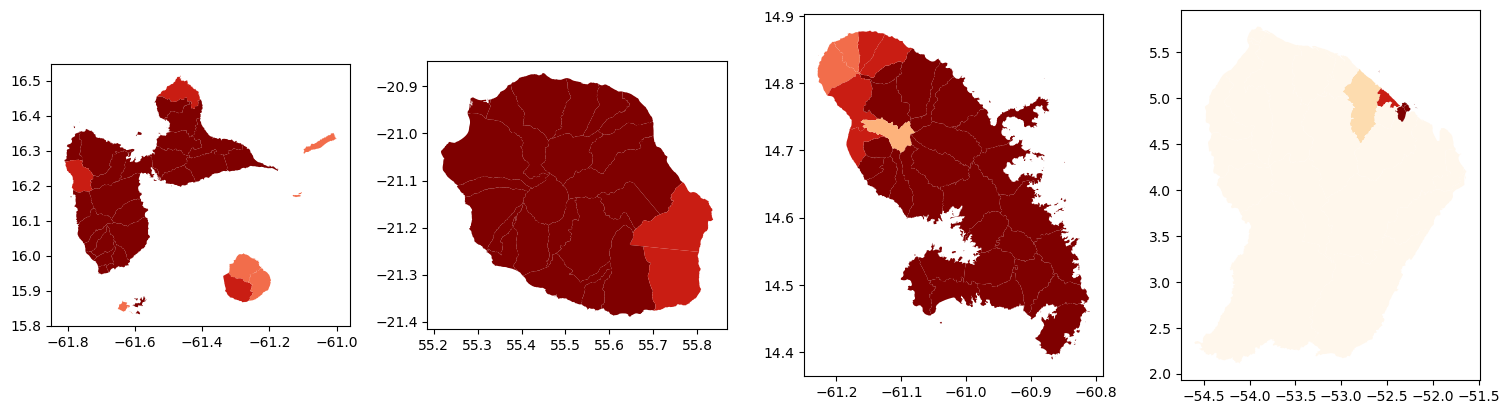

In [45]:
# Indicateur d'exposition des communes aux aléas climatiques
plot_climat_risque(data = [hexagone, guadeloupe,  reunion, martinique, guyane],
                    titles =['hexagone', 'guadeloupe', 'reunion', 'martinique', 'guyane'],
                    target = 'indice_expo')

Pour matotte on ne dispose pas de densité de la population

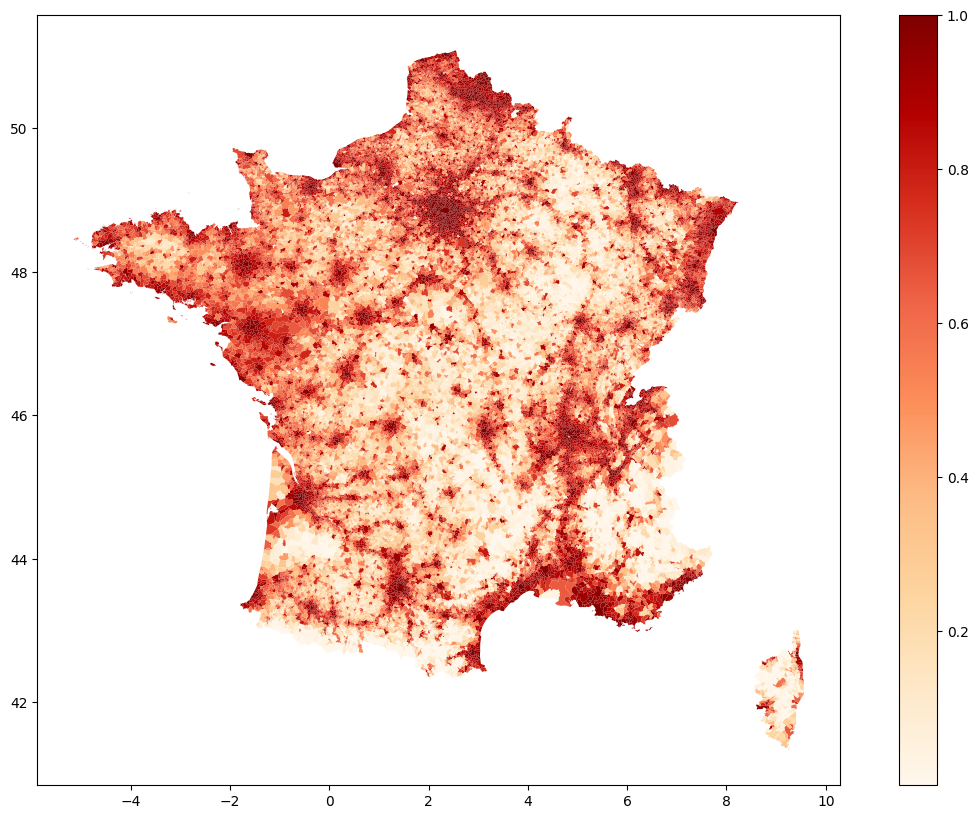

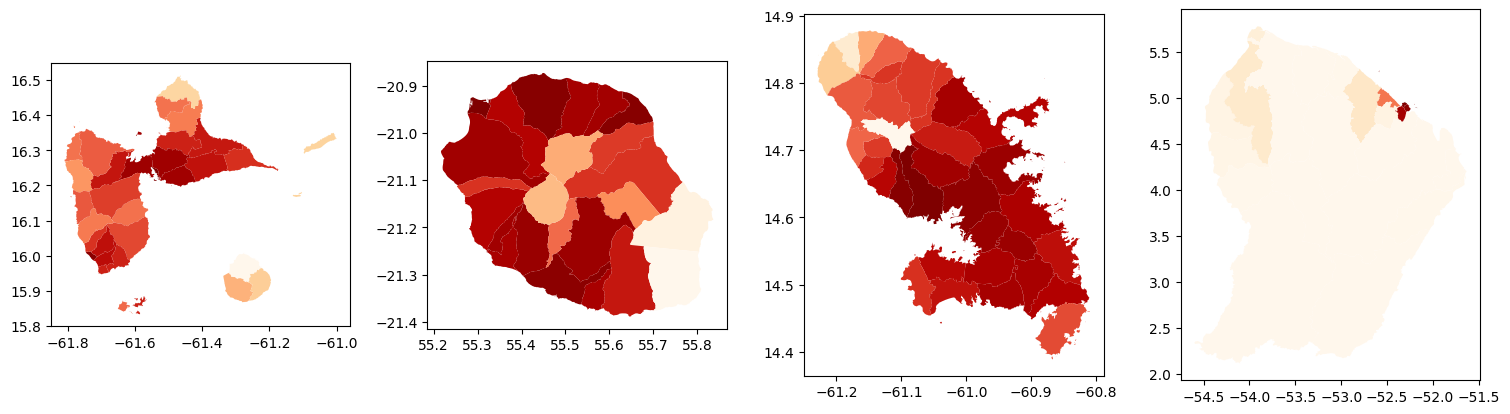

In [ ]:
# Quantile de densité de la population par commune
plot_climat_risque(data = [hexagone, guadeloupe,  reunion, martinique, guyane],
                    titles =['hexagone', 'guadeloupe', 'reunion', 'martinique', 'guyane'],
                    target = 'q_dens')

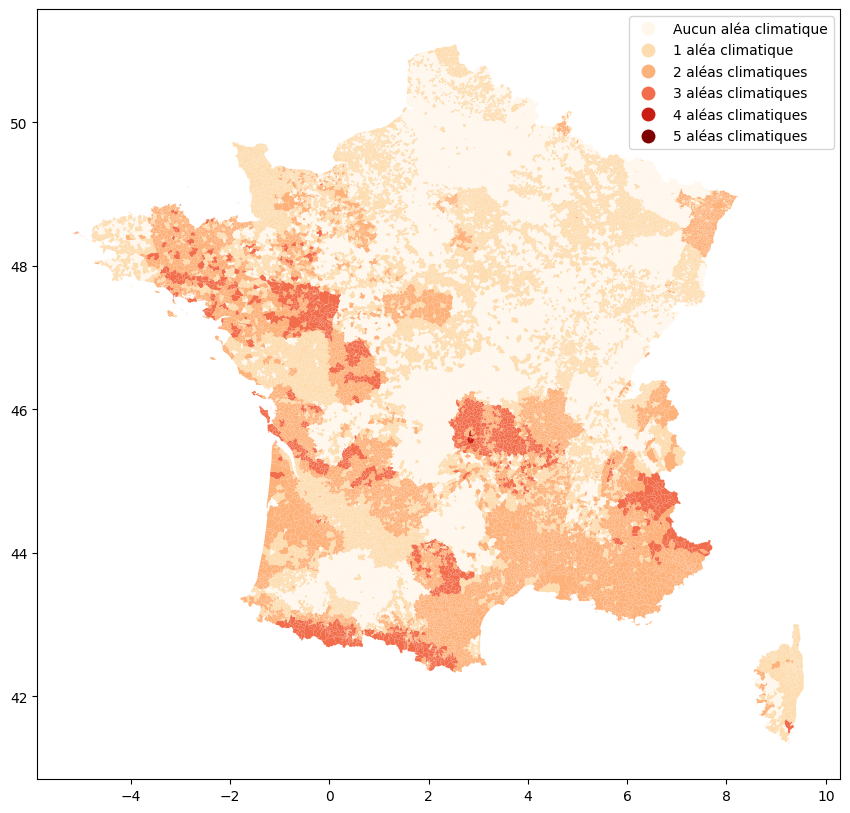

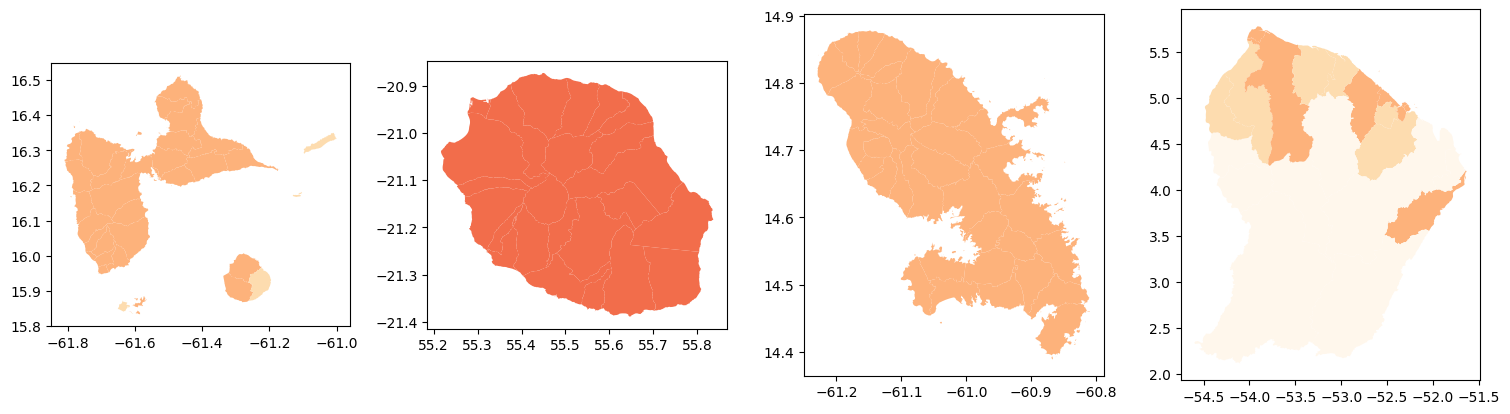

In [ ]:
# Nombre d'aléas climatiques sur chaque commune
plot_climat_risque(data = [hexagone, guadeloupe,  reunion, martinique, guyane],
                    titles =['hexagone', 'guadeloupe', 'reunion', 'martinique', 'guyane'],
                    target = 'nb_alea')

In [ ]:
hexagone.columns

Index(['cod_commune', 'cod_dep', 'geometry', 'lib_commune', 'Avalanche',
       'Feu de forêt', 'Inondation', 'Mouvement de Terrain',
       'Phénomène atmosphérique', 'nb_alea', 'note_alea', 'top_commune_chg',
       'dens_pop', 'top_dens_nan', 'q_dens', 'note_dens', 'note_expo',
       'indice_expo'],
      dtype='object')

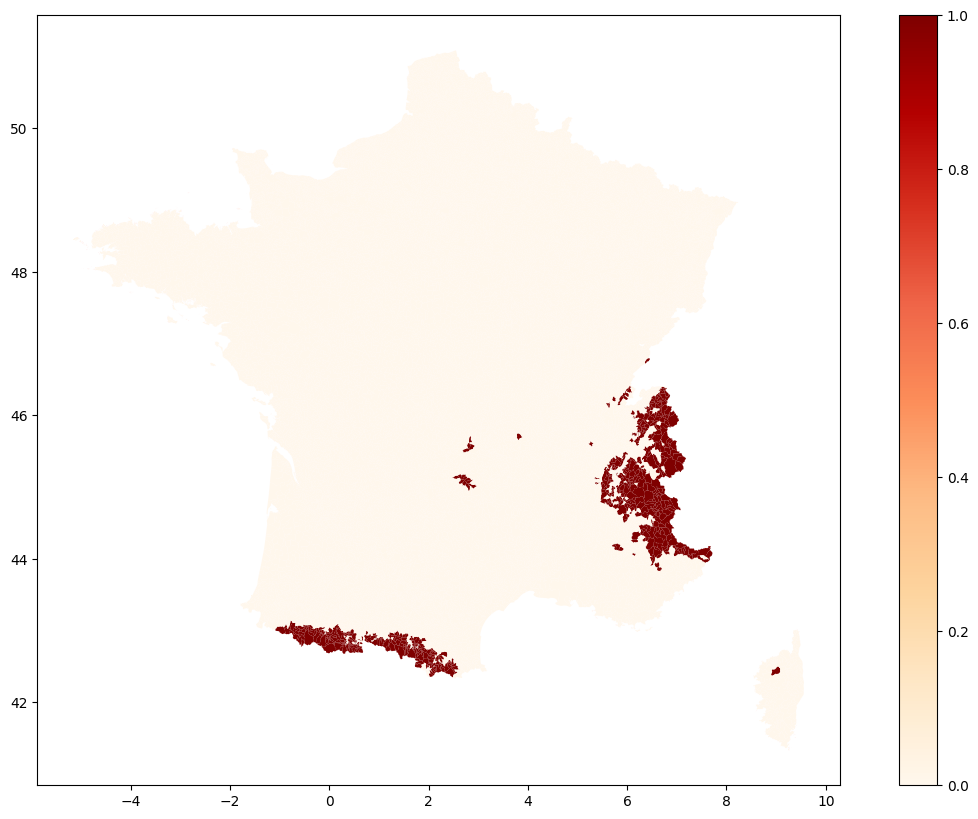

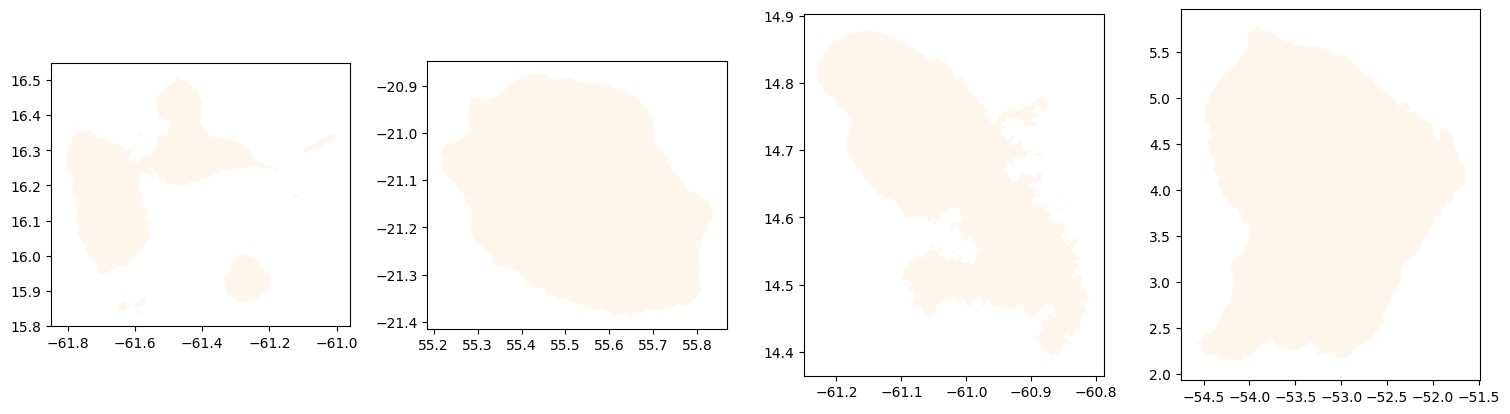

In [ ]:
# Communes exposées aux avalanches
plot_climat_risque(data = [hexagone, guadeloupe,  reunion, martinique, guyane],
                    titles =['hexagone', 'guadeloupe', 'reunion', 'martinique', 'guyane'],
                    target = 'Avalanche')

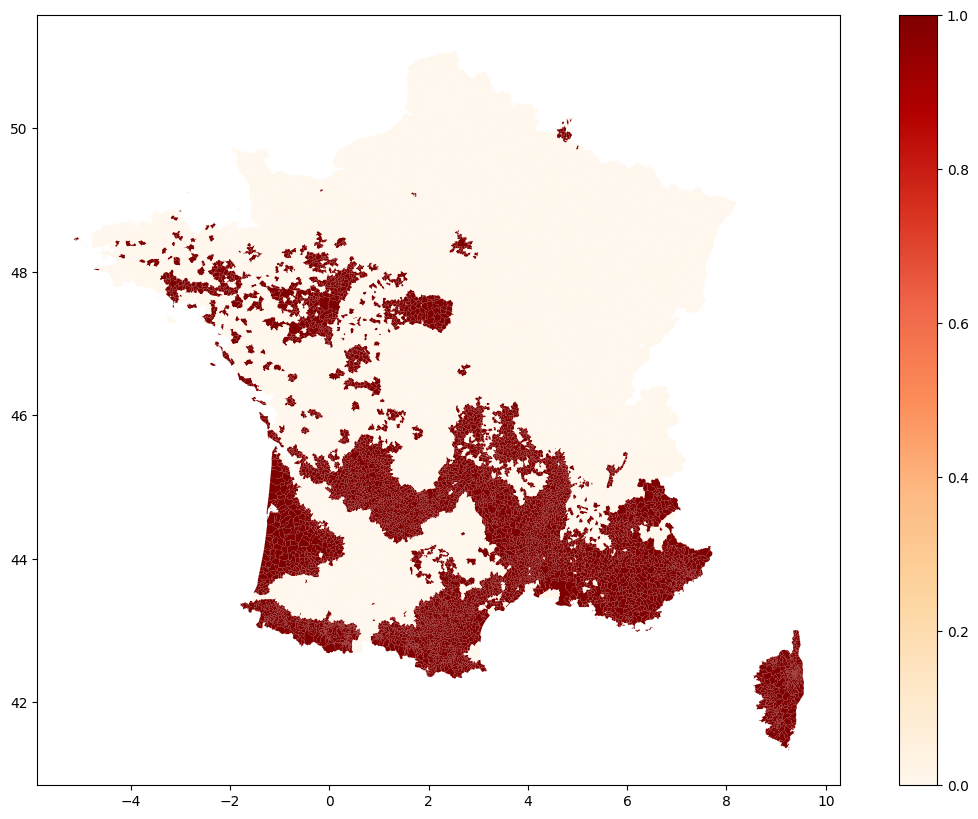

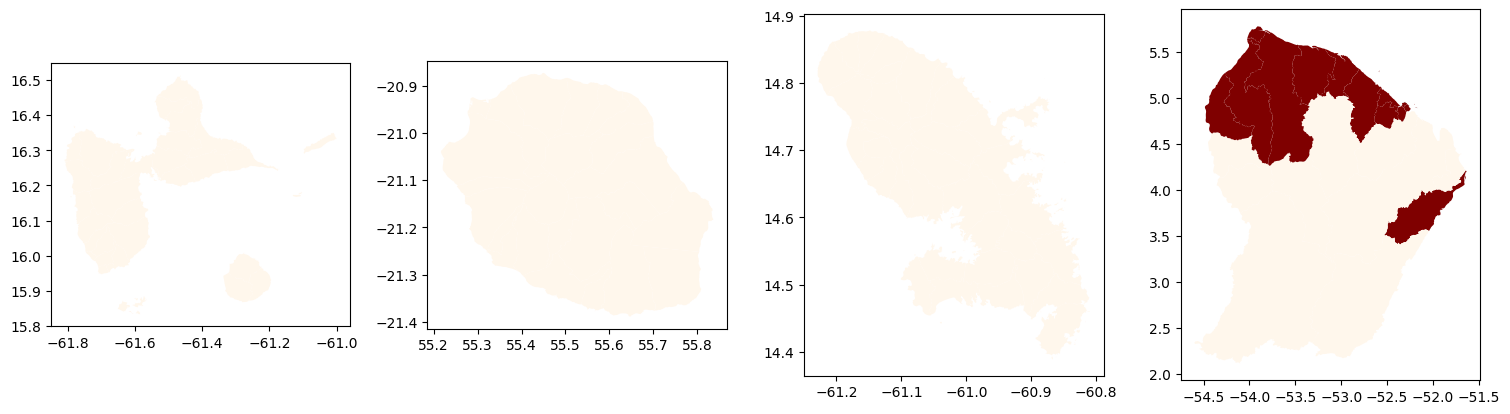

In [ ]:
# Communes exposées aux 'Feu de forêt'
plot_climat_risque(data = [hexagone, guadeloupe,  reunion, martinique, guyane],
                    titles =['hexagone', 'guadeloupe', 'reunion', 'martinique', 'guyane'],
                    target = 'Feu de forêt')

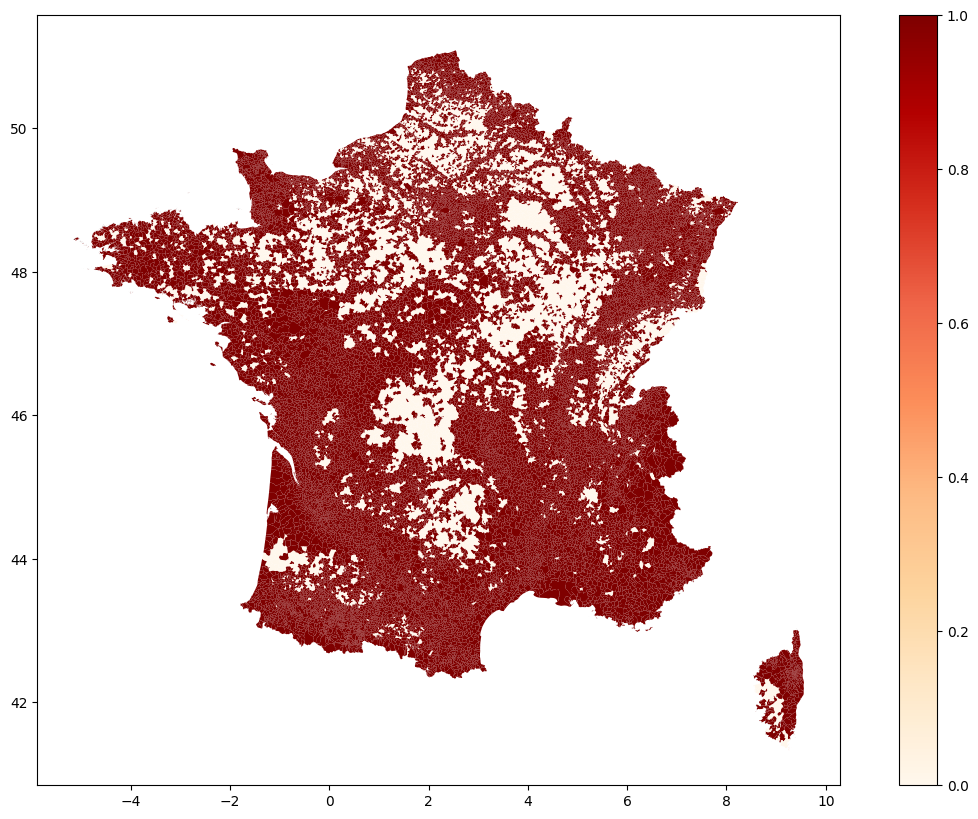

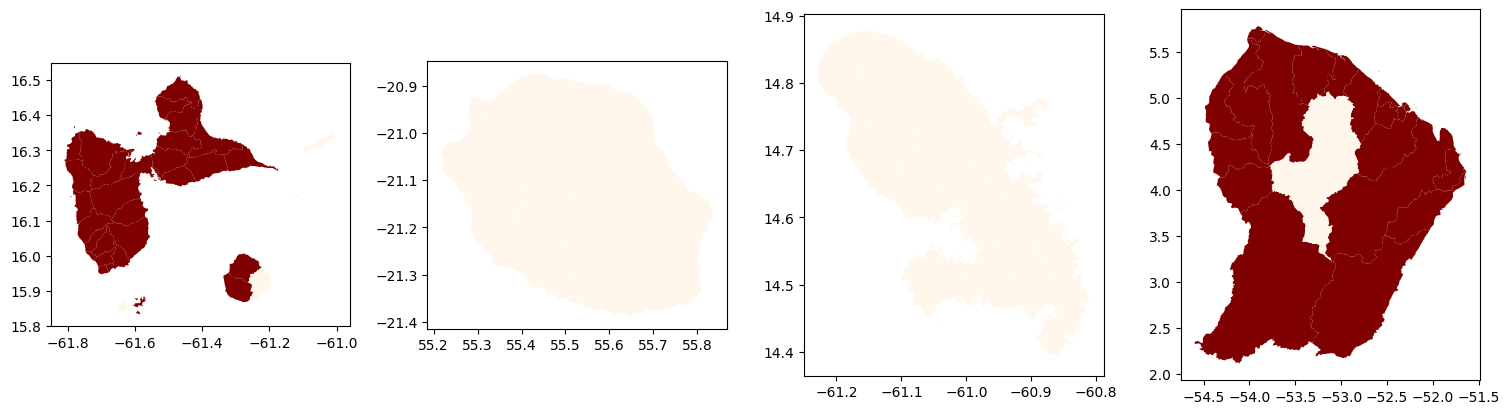

In [ ]:
# Communes exposées aux 'Inondation'
plot_climat_risque(data = [hexagone, guadeloupe,  reunion, martinique, guyane],
                    titles =['hexagone', 'guadeloupe', 'reunion', 'martinique', 'guyane'],
                    target = 'Inondation')

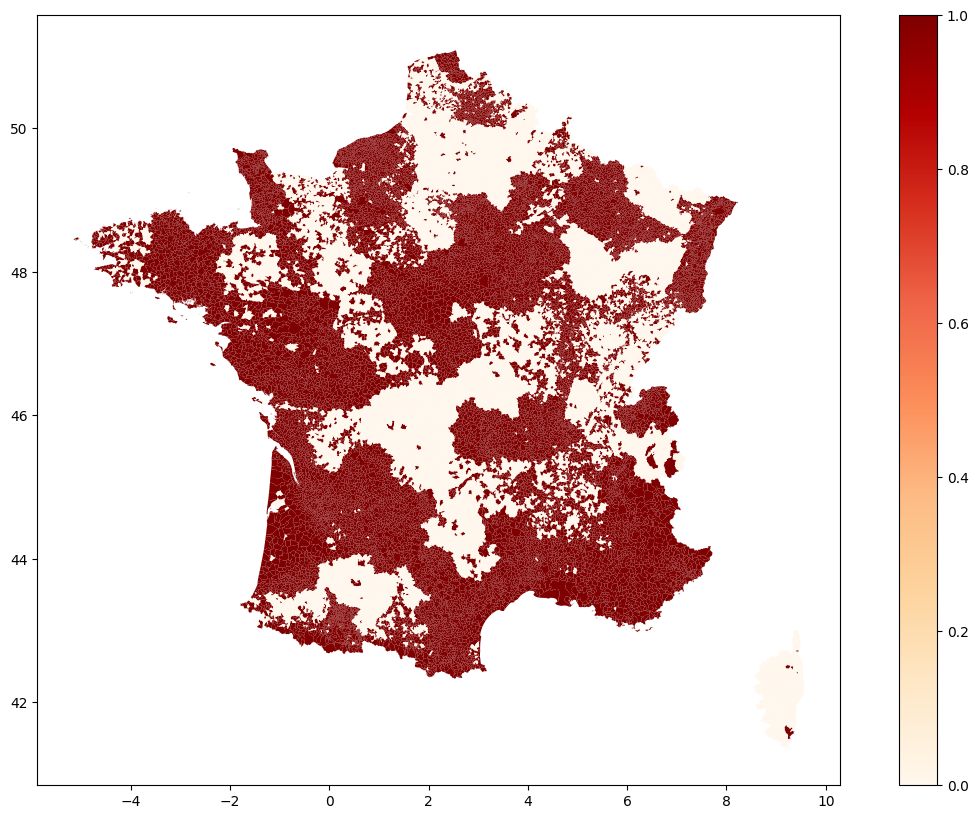

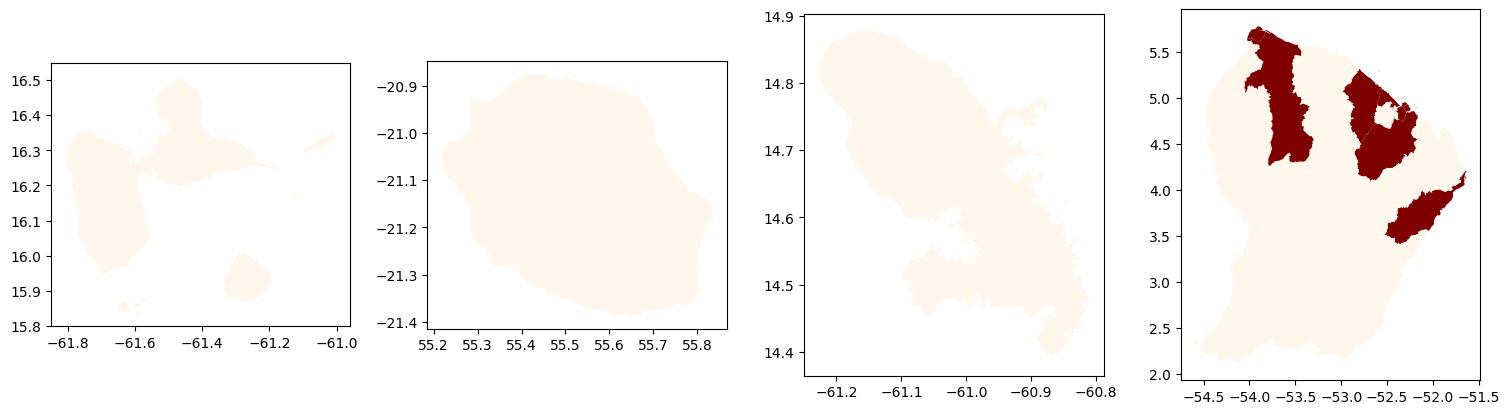

In [ ]:
# Communes exposées aux 'Mouvement de Terrain'
plot_climat_risque(data = [hexagone, guadeloupe,  reunion, martinique, guyane],
                    titles =['hexagone', 'guadeloupe', 'reunion', 'martinique', 'guyane'],
                    target = 'Mouvement de Terrain')

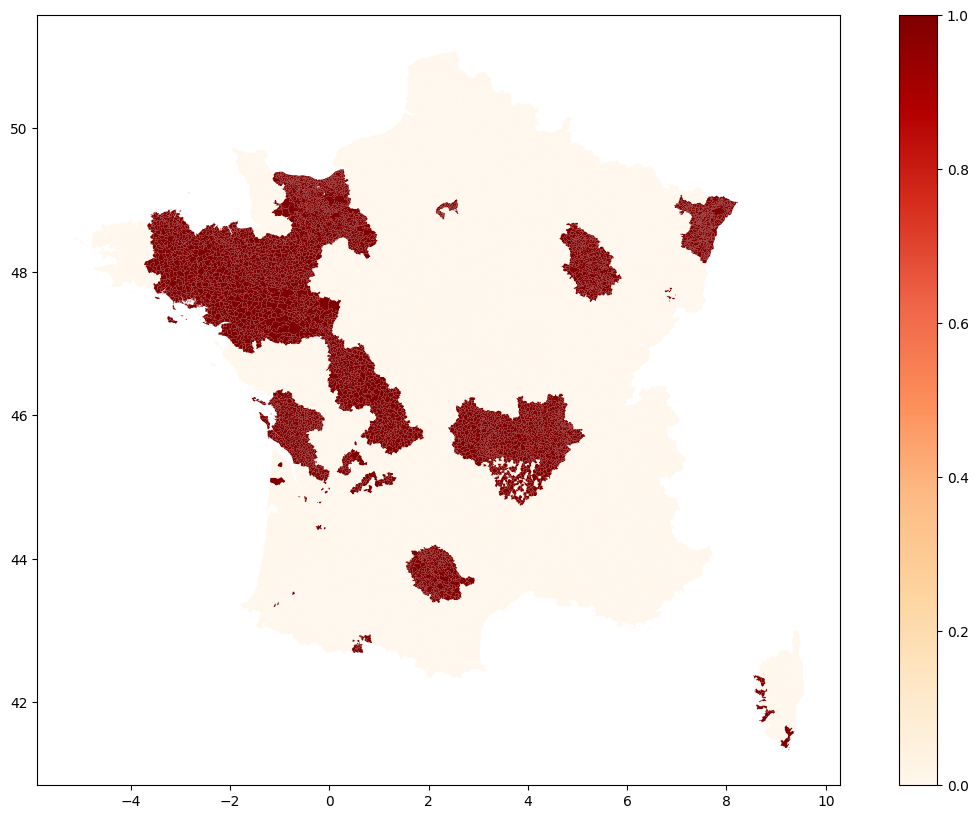

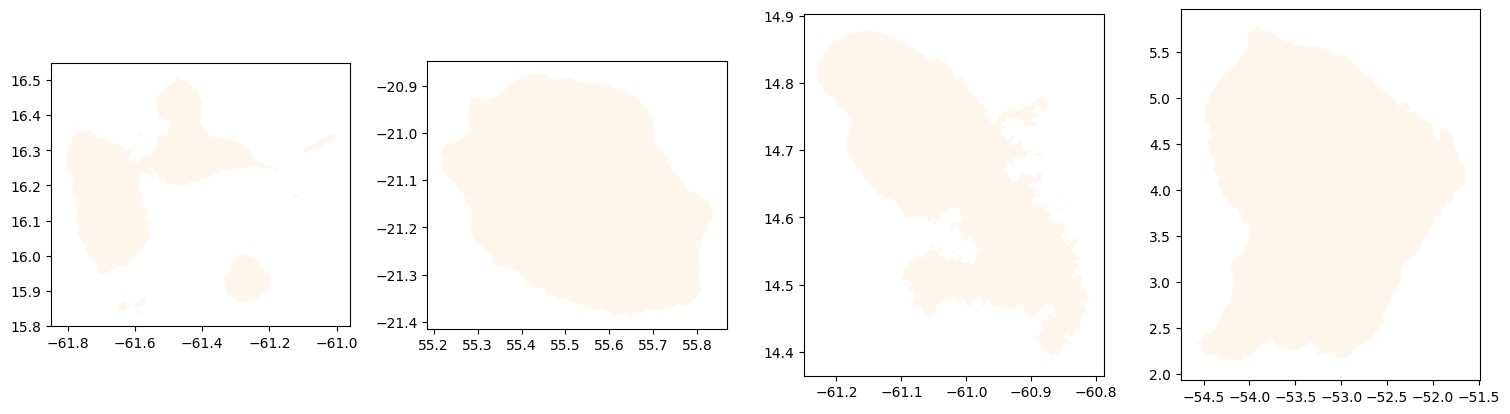

In [ ]:
# Communes exposées aux 'Phénomène atmosphérique'
plot_climat_risque(data = [hexagone, guadeloupe,  reunion, martinique, guyane],
                    titles =['hexagone', 'guadeloupe', 'reunion', 'martinique', 'guyane'],
                    target = 'Phénomène atmosphérique')